In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.0 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO
from pathlib import Path


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
MODEL_NAME='yolo11n-seg.pt'
DATASET_YAML="coco128-seg.yaml"
test_source="https://ultralytics.com/images/bus.jpg"
PROJECT_DIR="runs/local_segmentation"

In [7]:
model=YOLO(MODEL_NAME)

In [8]:
print("Running inference on test source...")
results=model.predict(
    source=test_source,
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project=PROJECT_DIR,
    name='pretrained_inference'
)

Running inference on test source...

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 59.4ms
Speed: 10.4ms preprocess, 59.4ms inference, 85.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/segment/runs/local_segmentation/pretrained_inference


In [9]:
model.train(
    data=DATASET_YAML,
    epochs=20,
    imgsz=640,
    batch=8,
    device=0,
    workers=4,
    project=PROJECT_DIR,
    name='finetune_coco128_seg',
)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128-seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune_coco128_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7da02924a2a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,

In [10]:
model.save('finetuned_yolov8n-seg.pt')

In [11]:
from google.colab import files
files.download('finetuned_yolov8n-seg.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
new_test_source = 'https://ultralytics.com/images/zidane.jpg'

In [13]:
print(f"Running inference on new test source: {new_test_source}")
new_results = model.predict(
    source=new_test_source,
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project=PROJECT_DIR,
    name='new_image_inference'
)

Running inference on new test source: https://ultralytics.com/images/zidane.jpg

image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 95.0ms
Speed: 1.8ms preprocess, 95.0ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/segment/runs/local_segmentation/new_image_inference


In [16]:
metrics = model.val(data=DATASET_YAML)
print(metrics)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,868,664 parameters, 0 gradients, 9.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1328.8±250.4 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128-seg/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 33.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 4.9s
                   all        128        929     0.0152     0.0165     0.0121    0.00481     0.0141    0.00963     0.0103    0.00447
                person         61        254    0.00379      0.504      0.102     0.0344    0.00213      0.283     0.0342    0.00721
               bicycle          3          6          0          0          0          0          0          0          0          0
                   car       

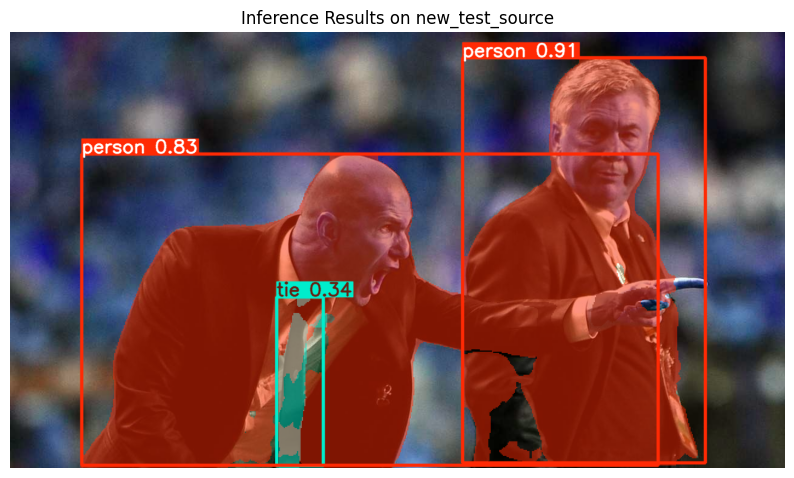

In [15]:
import matplotlib.pyplot as plt

# The plot method returns an annotated image (NumPy array)
annotated_image = new_results[0].plot()

plt.figure(figsize=(10, 10)) # Adjust figure size as needed
plt.imshow(annotated_image)
plt.axis('off') # Hide axes for a cleaner look
plt.title('Inference Results on new_test_source')
plt.show()